# XGBoost 임계값(Threshold) 탐색

**목표:** 이미 튜닝된 XGBoost 모델(`xgboost_tuned.pkl`)을 불러와
임계값을 **0.1 단위 (0.1 ~ 0.9)** 로 바꿔가며 성능을 비교하고,
각 임계값별로 `threshold_*.pkl` 파일을 저장합니다.

**저장 결과물:**
| 파일 | 설명 |
|---|---|
| `model/xgboost_threshold_01.pkl` ~ `09.pkl` | 임계값별 번들(파이프라인 + 임계값) |
| `output/threshold_results.csv` | 임계값별 성능 요약 |
| `output/threshold_comparison.png` | 성능 비교 시각화 |

## 1. 라이브러리 로드 및 환경 설정

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    fbeta_score,
    confusion_matrix,
    classification_report,
)
from sklearn.model_selection import train_test_split

# ── 경로 설정 (본인 환경에 맞게 수정) ───────────────────────
DATA_DIR   = Path("../data")
TRAIN_PATH = DATA_DIR / "cc_fraud_train_processed.csv"
TEST_PATH  = DATA_DIR / "cc_fraud_test_processed.csv"

MODEL_DIR  = Path('../model')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR = Path('../output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

sns.set_theme(style='whitegrid')
# ── 한글 폰트 설정 ───────────────────────────────────────────
plt.rcParams['font.family'] = 'Malgun Gothic'   # Windows
# plt.rcParams['font.family'] = 'AppleGothic'   # Mac
# plt.rcParams['font.family'] = 'NanumGothic'   # Linux
plt.rcParams['axes.unicode_minus'] = False

print('환경 설정 완료')

환경 설정 완료


## 2. 데이터 로드 및 분리

In [2]:
train = pd.read_csv(TRAIN_PATH)
train = train.loc[:, ~train.columns.str.contains(r'^Unnamed')]

test = pd.read_csv(TEST_PATH)
test = test.loc[:, ~test.columns.str.contains(r'^Unnamed')]

X = train.drop(columns=['is_fraud'])
y = train['is_fraud'].astype(int)

X_test = test.drop(columns=['is_fraud'])
y_test = test['is_fraud'].astype(int)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f'X_train: {X_train.shape}  |  X_valid: {X_valid.shape}  |  X_test: {X_test.shape}')
print(f'사기 비율 (train): {y_train.mean():.4f}')
print(f'사기 비율 (valid): {y_valid.mean():.4f}')
print(f'사기 비율 (test) : {y_test.mean():.4f}')

X_train: (1037340, 21)  |  X_valid: (259335, 21)  |  X_test: (555719, 21)
사기 비율 (train): 0.0058
사기 비율 (valid): 0.0058
사기 비율 (test) : 0.0039


## 3. 튜닝된 XGBoost 모델 로드

In [3]:
tuned_pipeline = joblib.load(MODEL_DIR / 'xgboost_tuned.pkl')
print('로드 완료')
print(tuned_pipeline)

로드 완료
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['amt', 'zip', 'lat', 'long',
                                                   'city_pop', 'unix_time',
                                                   'merch_lat', 'merch_long',
                                                   'trans_hour',
                                                   'trans_dayofweek',
                                                   'trans_month', 'trans_day',
                                                   'age', 'distance_km',
                                      

## 4. 확률값 예측 (Validation / Test)

In [4]:
valid_proba = tuned_pipeline.predict_proba(X_valid)[:, 1]
test_proba  = tuned_pipeline.predict_proba(X_test)[:, 1]

print(f'valid 예측 확률 범위: [{valid_proba.min():.4f}, {valid_proba.max():.4f}]')
print(f'test  예측 확률 범위: [{test_proba.min():.4f}, {test_proba.max():.4f}]')

valid 예측 확률 범위: [0.0000, 1.0000]
test  예측 확률 범위: [0.0000, 1.0000]


## 5. 임계값별 성능 비교 (0.1 단위)

각 임계값에서 **Validation / Test** 기준으로
Precision, Recall, F1, F2 및 혼동행렬(TP/FP/FN)을 계산합니다.

In [5]:
THRESHOLDS = np.round(np.arange(0.1, 1.0, 0.1), 1)  # [0.1, 0.2, ..., 0.9]

records = []

for thr in THRESHOLDS:
    # ── Valid 성능 ────────────────────────────────────────────
    v_pred = (valid_proba >= thr).astype(int)
    v_acc  = accuracy_score(y_valid, v_pred)
    v_prec = precision_score(y_valid, v_pred, zero_division=0)
    v_rec  = recall_score(y_valid, v_pred, zero_division=0)
    v_f1   = f1_score(y_valid, v_pred, zero_division=0)
    v_f2   = fbeta_score(y_valid, v_pred, beta=2, zero_division=0)
    v_roc  = roc_auc_score(y_valid, valid_proba)
    v_pr   = average_precision_score(y_valid, valid_proba)
    cm_v   = confusion_matrix(y_valid, v_pred)
    v_tn, v_fp, v_fn, v_tp = cm_v.ravel()

    # ── Test 성능 ─────────────────────────────────────────────
    t_pred = (test_proba >= thr).astype(int)
    t_acc  = accuracy_score(y_test, t_pred)
    t_prec = precision_score(y_test, t_pred, zero_division=0)
    t_rec  = recall_score(y_test, t_pred, zero_division=0)
    t_f1   = f1_score(y_test, t_pred, zero_division=0)
    t_f2   = fbeta_score(y_test, t_pred, beta=2, zero_division=0)
    cm_t   = confusion_matrix(y_test, t_pred)
    t_tn, t_fp, t_fn, t_tp = cm_t.ravel()

    records.append({
        'threshold':   thr,
        # Valid
        'v_accuracy':  round(v_acc,  4),
        'v_precision': round(v_prec, 4),
        'v_recall':    round(v_rec,  4),
        'v_f1':        round(v_f1,   4),
        'v_f2':        round(v_f2,   4),
        'v_roc_auc':   round(v_roc,  4),
        'v_pr_auc':    round(v_pr,   4),
        'v_TP': int(v_tp), 'v_FP': int(v_fp),
        'v_FN': int(v_fn), 'v_TN': int(v_tn),
        # Test
        't_accuracy':  round(t_acc,  4),
        't_precision': round(t_prec, 4),
        't_recall':    round(t_rec,  4),
        't_f1':        round(t_f1,   4),
        't_f2':        round(t_f2,   4),
        't_TP': int(t_tp), 't_FP': int(t_fp),
        't_FN': int(t_fn), 't_TN': int(t_tn),
    })

results_df = pd.DataFrame(records)
print('임계값별 성능 (Valid 기준)')
display(results_df[['threshold',
                     'v_precision', 'v_recall', 'v_f1', 'v_f2',
                     'v_TP', 'v_FP', 'v_FN']])

임계값별 성능 (Valid 기준)


,threshold,v_precision,v_recall,v_f1,v_f2,v_TP,v_FP,v_FN
0,0.1,0.7336,0.9634,0.8329,0.9066,1446,525,55
1,0.2,0.8009,0.9540,0.8708,0.9189,1432,356,69
2,0.3,0.8396,0.9487,0.8908,0.9247,1424,272,77
3,0.4,0.8728,0.9460,0.9079,0.9304,1420,207,81
4,0.5,0.8957,0.9387,0.9167,0.9298,1409,164,92
5,0.6,0.9200,0.9347,0.9273,0.9317,1403,122,98
6,0.7,0.9404,0.9247,0.9325,0.9278,1388,88,113
7,0.8,0.9616,0.9181,0.9393,0.9264,1378,55,123
8,0.9,0.9768,0.8994,0.9365,0.9139,1350,32,151


## 6. 결과 CSV 저장

In [6]:
csv_path = OUTPUT_DIR / 'threshold_results.csv'
results_df.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f'저장 완료 → {csv_path.resolve()}')

저장 완료 → D:\Lecture\03_Bootcamp\Teamproject\output\threshold_results.csv


## 7. 성능 비교 시각화

- **(좌상)** Validation — Precision / Recall / F1 / F2
- **(우상)** Test — Precision / Recall / F1 / F2
- **(좌하)** Validation — TP / FP / FN 건수
- **(우하)** Test — TP / FP / FN 건수

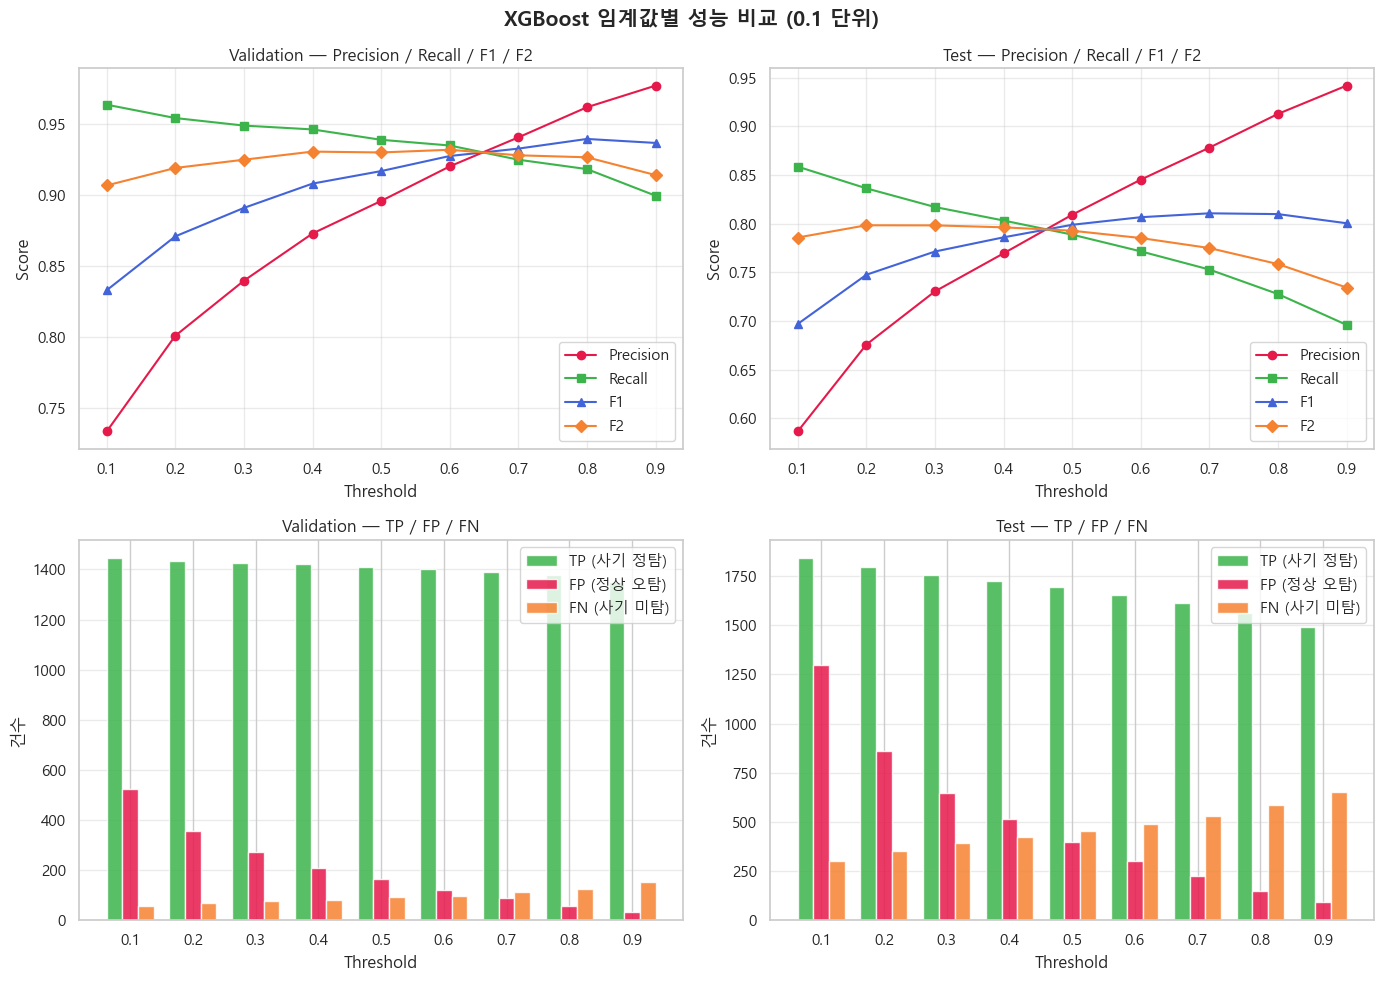

시각화 저장 완료 → D:\Lecture\03_Bootcamp\Teamproject\output\threshold_comparison.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('XGBoost 임계값별 성능 비교 (0.1 단위)', fontsize=15, fontweight='bold')

thr_vals = results_df['threshold']

# ── (1) Valid: Precision / Recall / F1 / F2 ───────────────
ax = axes[0, 0]
ax.plot(thr_vals, results_df['v_precision'], 'o-', label='Precision', color='#e6194b')
ax.plot(thr_vals, results_df['v_recall'],    's-', label='Recall',    color='#3cb44b')
ax.plot(thr_vals, results_df['v_f1'],        '^-', label='F1',        color='#4363d8')
ax.plot(thr_vals, results_df['v_f2'],        'D-', label='F2',        color='#f58231')
ax.set_title('Validation — Precision / Recall / F1 / F2')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_xticks(thr_vals)
ax.legend()
ax.grid(True, alpha=0.4)

# ── (2) Test: Precision / Recall / F1 / F2 ────────────────
ax = axes[0, 1]
ax.plot(thr_vals, results_df['t_precision'], 'o-', label='Precision', color='#e6194b')
ax.plot(thr_vals, results_df['t_recall'],    's-', label='Recall',    color='#3cb44b')
ax.plot(thr_vals, results_df['t_f1'],        '^-', label='F1',        color='#4363d8')
ax.plot(thr_vals, results_df['t_f2'],        'D-', label='F2',        color='#f58231')
ax.set_title('Test — Precision / Recall / F1 / F2')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_xticks(thr_vals)
ax.legend()
ax.grid(True, alpha=0.4)

# ── (3) Valid: TP / FP / FN ───────────────────────────────
ax = axes[1, 0]
ax.bar(thr_vals - 0.025, results_df['v_TP'], width=0.025, label='TP (사기 정탐)', color='#3cb44b', alpha=0.85)
ax.bar(thr_vals,         results_df['v_FP'], width=0.025, label='FP (정상 오탐)', color='#e6194b', alpha=0.85)
ax.bar(thr_vals + 0.025, results_df['v_FN'], width=0.025, label='FN (사기 미탐)', color='#f58231', alpha=0.85)
ax.set_title('Validation — TP / FP / FN')
ax.set_xlabel('Threshold')
ax.set_ylabel('건수')
ax.set_xticks(thr_vals)
ax.legend()
ax.grid(True, alpha=0.4, axis='y')

# ── (4) Test: TP / FP / FN ────────────────────────────────
ax = axes[1, 1]
ax.bar(thr_vals - 0.025, results_df['t_TP'], width=0.025, label='TP (사기 정탐)', color='#3cb44b', alpha=0.85)
ax.bar(thr_vals,         results_df['t_FP'], width=0.025, label='FP (정상 오탐)', color='#e6194b', alpha=0.85)
ax.bar(thr_vals + 0.025, results_df['t_FN'], width=0.025, label='FN (사기 미탐)', color='#f58231', alpha=0.85)
ax.set_title('Test — TP / FP / FN')
ax.set_xlabel('Threshold')
ax.set_ylabel('건수')
ax.set_xticks(thr_vals)
ax.legend()
ax.grid(True, alpha=0.4, axis='y')

plt.tight_layout()
img_path = OUTPUT_DIR / 'threshold_comparison.png'
plt.savefig(img_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'시각화 저장 완료 → {img_path.resolve()}')

## 8. 임계값별 pkl 저장

파이프라인과 임계값을 딕셔너리로 묶어 저장합니다.

```python
# 불러올 때
bundle    = joblib.load('model/xgboost_threshold_03.pkl')
pipeline  = bundle['pipeline']   # 전처리 + XGBoost
threshold = bundle['threshold']  # 0.3

proba = pipeline.predict_proba(X_new)[:, 1]
pred  = (proba >= threshold).astype(int)
```

In [8]:
for thr in THRESHOLDS:
    bundle = {
        'pipeline':  tuned_pipeline,
        'threshold': float(thr),
    }
    fname = MODEL_DIR / f'xgboost_threshold_{int(thr * 10):02d}.pkl'
    joblib.dump(bundle, fname)
    print(f'저장 완료 → {fname.name}')

저장 완료 → xgboost_threshold_01.pkl
저장 완료 → xgboost_threshold_02.pkl
저장 완료 → xgboost_threshold_03.pkl
저장 완료 → xgboost_threshold_04.pkl
저장 완료 → xgboost_threshold_05.pkl
저장 완료 → xgboost_threshold_06.pkl
저장 완료 → xgboost_threshold_07.pkl
저장 완료 → xgboost_threshold_08.pkl
저장 완료 → xgboost_threshold_09.pkl


## 9. 최적 임계값 추천

- **F2 기준**: Recall 중시 (사기 미탐 최소화)
- **F1 기준**: Precision ↔ Recall 균형

In [9]:
best_f2_row = results_df.loc[results_df['v_f2'].idxmax()]
best_f1_row = results_df.loc[results_df['v_f1'].idxmax()]

print('=' * 50)
print(f"F2 최대 임계값 : {best_f2_row['threshold']:.1f}")
print(f"  F2={best_f2_row['v_f2']:.4f}  Recall={best_f2_row['v_recall']:.4f}  Precision={best_f2_row['v_precision']:.4f}")
print()
print(f"F1 최대 임계값 : {best_f1_row['threshold']:.1f}")
print(f"  F1={best_f1_row['v_f1']:.4f}  Recall={best_f1_row['v_recall']:.4f}  Precision={best_f1_row['v_precision']:.4f}")
print('=' * 50)

# 전체 결과 요약
print('\n[전체 결과 요약]')
display(results_df[['threshold',
                     'v_precision', 'v_recall', 'v_f1', 'v_f2',
                     't_precision', 't_recall', 't_f1', 't_f2']])

F2 최대 임계값 : 0.6
  F2=0.9317  Recall=0.9347  Precision=0.9200

F1 최대 임계값 : 0.8
  F1=0.9393  Recall=0.9181  Precision=0.9616

[전체 결과 요약]


,threshold,v_precision,v_recall,v_f1,v_f2,t_precision,t_recall,t_f1,t_f2
0,0.1,0.7336,0.9634,0.8329,0.9066,0.5864,0.8587,0.6969,0.7858
1,0.2,0.8009,0.9540,0.8708,0.9189,0.6757,0.8364,0.7475,0.7984
2,0.3,0.8396,0.9487,0.8908,0.9247,0.7304,0.8172,0.7714,0.7983
3,0.4,0.8728,0.9460,0.9079,0.9304,0.7695,0.8033,0.7860,0.7963
4,0.5,0.8957,0.9387,0.9167,0.9298,0.8092,0.7888,0.7989,0.7928
5,0.6,0.9200,0.9347,0.9273,0.9317,0.8453,0.7716,0.8067,0.7853
6,0.7,0.9404,0.9247,0.9325,0.9278,0.8782,0.7529,0.8107,0.7750
7,0.8,0.9616,0.9181,0.9393,0.9264,0.9129,0.7277,0.8099,0.7585
8,0.9,0.9768,0.8994,0.9365,0.9139,0.9420,0.6960,0.8005,0.7344
